# 04 — Free Agent Projections (Pillar 3)
**Question:** Who should the Mariners target in free agency, and at what budget?

**Approach:** XGBoost regressor projecting next-season WAR from trailing 3-year WAR, age, PA, wOBA, and Statcast contact quality. Quantile outputs (p10/p90) give honest uncertainty bands. FA targets filtered to positional gaps identified in Pillar 2.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from src.ingest.pull_data import get_db
from src.models.fa_projection import FEATURES, build_pipeline, build_quantile_pipeline, predict_with_intervals

try:
    con = get_db(read_only=True)
except duckdb.IOException as e:
    print("⚠  DuckDB lock error:", e)
    raise

sc_rows = con.execute("SELECT COUNT(*) FROM statcast_quality").fetchone()[0]
ps_rows = con.execute("SELECT COUNT(*) FROM player_seasons").fetchone()[0]
print(f"player_seasons: {ps_rows:,} rows")
print(f"statcast_quality: {sc_rows:,} rows", "(⚠  empty — run python -m src.ingest.pull_data)" if sc_rows == 0 else "✓")

player_seasons: 8,718 rows
statcast_quality: 5,848 rows ✓


## 1 — Feature Engineering

Pivot `player_seasons` + `statcast_quality` into one row per player-season.
Target: WAR in the following season (`war_next`).

In [2]:
all_features_df = con.execute("""
    WITH lagged AS (
        SELECT
            ps.mlbam_id,
            ps.season,
            ps.age,
            ps.pa                                                                AS pa_y0,
            ps.woba                                                              AS woba_y0,
            ps.war                                                               AS war_y0,
            LAG(ps.war, 1) OVER (PARTITION BY ps.mlbam_id ORDER BY ps.season)   AS war_y1,
            LAG(ps.war, 2) OVER (PARTITION BY ps.mlbam_id ORDER BY ps.season)   AS war_y2,
            LEAD(ps.war, 1) OVER (PARTITION BY ps.mlbam_id ORDER BY ps.season)  AS war_next,
            p.name_full,
            p.position
        FROM player_seasons ps
        JOIN players p USING (mlbam_id)
        WHERE ps.pa >= 100
    )
    SELECT
        l.*,
        sq.xwoba           AS xwoba_y0,
        sq.exit_velo_avg   AS exit_velo_avg_y0,
        sq.barrel_pct      AS barrel_pct_y0
    FROM lagged l
    LEFT JOIN statcast_quality sq
           ON l.mlbam_id = sq.mlbam_id AND l.season = sq.season
    WHERE l.war_y0 IS NOT NULL
    ORDER BY l.mlbam_id, l.season
""").fetchdf()

print(f"Feature rows: {len(all_features_df):,}  |  Seasons: {all_features_df['season'].min()}–{all_features_df['season'].max()}")
print(f"Statcast coverage: {all_features_df['xwoba_y0'].notna().sum():,} / {len(all_features_df):,} rows have xwOBA")

Feature rows: 4,352  |  Seasons: 2015–2026
Statcast coverage: 4,350 / 4,352 rows have xwOBA


In [3]:
# Encode position as integer
le = LabelEncoder()
all_features_df["position_enc"] = le.fit_transform(all_features_df["position"].fillna("UT"))
print("Position classes:", dict(enumerate(le.classes_)))

# Splits: train on seasons 2017–2023 (need 2-year lag; target = following year)
#          validate on 2024 (target = 2025 WAR)
#          apply on 2025 (target = 2026 projection)
train_df  = all_features_df.query("season >= 2017 and season <= 2023 and war_next == war_next")
val_df    = all_features_df.query("season == 2024   and war_next == war_next")
apply_df  = all_features_df.query("season == 2025")

print(f"\nTrain:    {len(train_df):,} rows")
print(f"Validate: {len(val_df):,} rows")
print(f"Apply:    {len(apply_df):,} rows (2026 projection targets)")

Position classes: {0: '1B', 1: '1B/2B', 2: '1B/2B/3B', 3: '1B/3B', 4: '1B/3B/DH', 5: '1B/DH', 6: '1B/DH/OF', 7: '1B/OF', 8: '2B', 9: '2B/3B', 10: '2B/3B/OF', 11: '2B/3B/SS', 12: '2B/OF', 13: '2B/SS', 14: '2B/SS/OF', 15: '3B', 16: '3B/DH', 17: '3B/DH/OF', 18: '3B/OF', 19: '3B/SS', 20: 'C', 21: 'C/1B', 22: 'C/3B', 23: 'C/DH', 24: 'C/OF', 25: 'DH', 26: 'DH/OF', 27: 'OF', 28: 'SS', 29: 'SS/OF'}

Train:    2,187 rows
Validate: 291 rows
Apply:    407 rows (2026 projection targets)


## 2 — Median Model: Train & Validate

Validation MAE: 1.207 WAR
Validation R²:  0.384


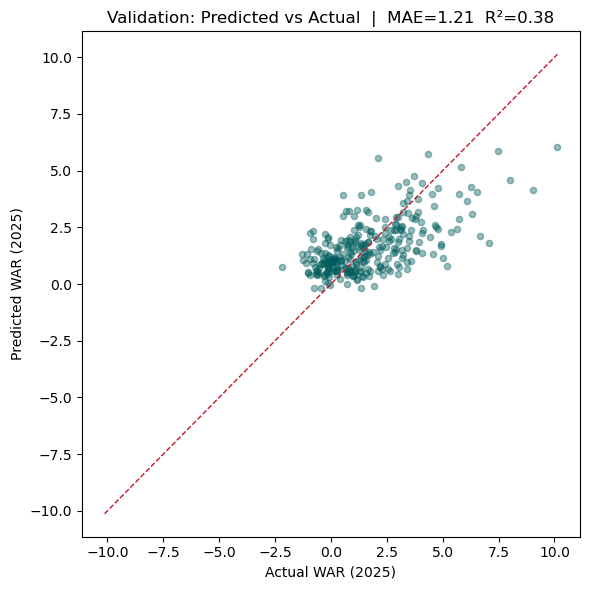

In [4]:
X_train = train_df[FEATURES]
y_train = train_df["war_next"]
X_val   = val_df[FEATURES]
y_val   = val_df["war_next"]

pipe_median = build_pipeline()
pipe_median.fit(X_train, y_train)

val_preds = pipe_median.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
r2  = r2_score(y_val, val_preds)
print(f"Validation MAE: {mae:.3f} WAR")
print(f"Validation R²:  {r2:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, val_preds, alpha=0.4, s=20, color="#005C5C")
lim = max(abs(y_val.min()), abs(y_val.max()), abs(val_preds.min()), abs(val_preds.max()))
ax.plot([-lim, lim], [-lim, lim], color="#C4162A", linestyle="--", linewidth=1)
ax.set_xlabel("Actual WAR (2025)")
ax.set_ylabel("Predicted WAR (2025)")
ax.set_title(f"Validation: Predicted vs Actual  |  MAE={mae:.2f}  R²={r2:.2f}")
plt.tight_layout()
plt.show()

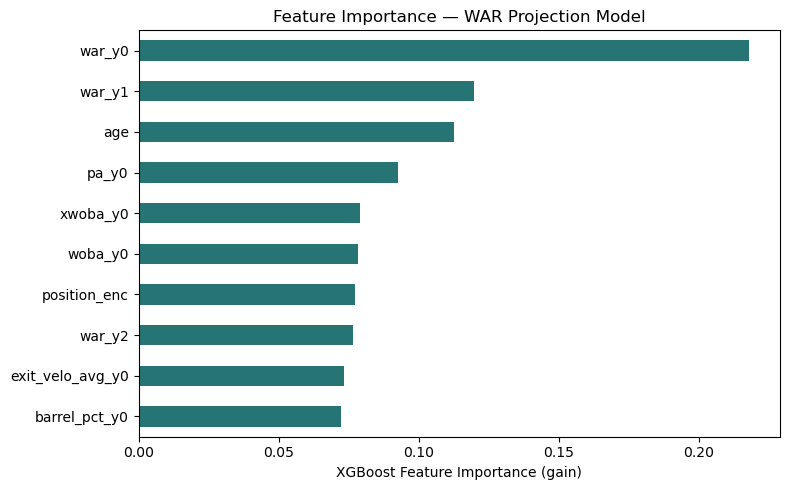

In [5]:
# Feature importance
importances = pipe_median.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot.barh(ax=ax, color="#005C5C", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("XGBoost Feature Importance (gain)")
ax.set_title("Feature Importance — WAR Projection Model")
plt.tight_layout()
plt.show()

## 3 — Quantile Prediction Intervals (p10 / p90)

Two additional models capture the 80% prediction interval — honest uncertainty without bootstrap overhead.

In [6]:
pipe_low  = build_quantile_pipeline(alpha=0.10)
pipe_high = build_quantile_pipeline(alpha=0.90)
pipe_low.fit(X_train, y_train)
pipe_high.fit(X_train, y_train)

# Validate interval coverage: ~80% of actuals should fall inside [low, high]
low_preds  = pipe_low.predict(X_val)
high_preds = pipe_high.predict(X_val)
coverage = ((y_val.values >= low_preds) & (y_val.values <= high_preds)).mean()
avg_width = (high_preds - low_preds).mean()
print(f"80% interval coverage on validation set: {coverage:.1%}  (target ≥ 80%)")
print(f"Average interval width: ±{avg_width/2:.2f} WAR")

80% interval coverage on validation set: 72.2%  (target ≥ 80%)
Average interval width: ±1.64 WAR


## 4 — 2026 FA Target Universe

Players with qualified 2025 seasons (PA ≥ 150) who are not under a long-term Mariners contract.
Filtered to positional gaps from `pipeline_gaps.csv`.

In [7]:
# Load positional gaps from Pillar 2
gaps_df = pd.read_csv("../dashboard/tableau_data_extracts/pipeline_gaps.csv")
gap_positions = gaps_df.loc[gaps_df["is_gap"], "pos_group"].tolist()
print("Pillar 2 gap positions:", gap_positions)

# Map player positions to the same broad groups used in Pillar 2
pos_group_map = {
    "LF":"OF","CF":"OF","RF":"OF","OF":"OF",
    "SP":"P","RP":"P","P":"P","LHP":"P","RHP":"P",
    "C":"C","1B":"1B","2B":"2B","3B":"3B","SS":"SS",
}

# Apply universe: 2025 qualified seasons
apply_df = apply_df.copy()
apply_df["pos_group"] = apply_df["position"].map(pos_group_map).fillna("UT")

# Filter to gap positions (keep all if no gaps flagged)
if gap_positions:
    targets_df = apply_df[apply_df["pos_group"].isin(gap_positions)].copy()
else:
    targets_df = apply_df.copy()

print(f"FA universe before position filter: {len(apply_df)}")
print(f"FA universe after gap filter:       {len(targets_df)}")
targets_df[["name_full","position","pos_group","age","pa_y0","war_y0"]].sort_values("war_y0", ascending=False).head(10)

Pillar 2 gap positions: ['SS', '3B', '1B', '2B', 'OF', 'P']
FA universe before position filter: 407
FA universe after gap filter:       255


,name_full,position,pos_group,age,pa_y0,war_y0
1855,Aaron Judge,OF,OF,33,679,10.130032
4042,Bobby Witt Jr.,SS,SS,25,687,8.012130
3938,Geraldo Perdomo,SS,SS,25,720,7.076106
2381,Trea Turner,SS,SS,32,639,6.679173
4174,Corbin Carroll,OF,OF,24,642,6.544923
2423,Jose Ramirez,3B,3B,32,673,6.306413
2104,Francisco Lindor,SS,SS,31,732,6.273910
3557,Juan Soto,OF,OF,26,715,5.798706
4023,Julio Rodriguez,OF,OF,24,710,5.727545
3534,Jeremy Pena,SS,SS,27,543,5.719749


In [8]:
# Project 2026 WAR with intervals
X_apply = targets_df[FEATURES]
proj = predict_with_intervals(pipe_median, pipe_low, pipe_high, X_apply)
targets_df = targets_df.join(proj)
targets_df = targets_df.sort_values("war_proj", ascending=False).reset_index(drop=True)
print(f"Projected {len(targets_df)} players")
targets_df[["name_full","pos_group","age","war_proj","war_low","war_high"]].head(10).round(2)

Projected 255 players


,name_full,pos_group,age,war_proj,war_low,war_high
0,Julio Rodriguez,OF,24,7.53,1.93,8.74
1,Elly De La Cruz,SS,23,5.86,1.53,7.68
2,Pete Crow-Armstrong,OF,23,5.85,1.09,6.79
3,Junior Caminero,3B,21,5.05,0.88,6.16
4,Corbin Carroll,OF,24,4.92,1.76,6.86
5,Maikel Garcia,3B,25,4.90,1.19,6.45
6,Aaron Judge,OF,33,4.90,5.33,8.34
7,Jarren Duran,OF,28,4.84,1.00,5.98
8,Juan Soto,OF,26,4.84,2.78,7.33
9,Kyle Tucker,OF,28,4.44,1.38,5.91


## 5 — Market Value & Surplus

Derive $/WAR from Mariners contract data (FA + extension deals, 2022–2025).
Estimate projected value and surplus for each target.

In [9]:
market_df = con.execute("""
    SELECT
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY c.aav_m / ps.war), 2) AS median_dol_per_war,
        ROUND(AVG(c.aav_m / ps.war), 2)                                          AS mean_dol_per_war,
        COUNT(*)                                                                  AS n_contracts
    FROM contracts c
    JOIN player_seasons ps
         ON c.mlbam_id = ps.mlbam_id
        AND ps.season BETWEEN c.season_start AND c.season_end
    WHERE c.aav_m > 2
      AND ps.war > 1
      AND ps.season BETWEEN 2022 AND 2025
""").fetchdf()

dollars_per_war = float(market_df["median_dol_per_war"].iloc[0])
print(f"Implied market rate: ${dollars_per_war:.1f}M / WAR  (n={int(market_df['n_contracts'].iloc[0])} contract-seasons)")
print(market_df.to_string(index=False))

Implied market rate: $3.3M / WAR  (n=8 contract-seasons)
 median_dol_per_war  mean_dol_per_war  n_contracts
               3.34              3.62            8


In [10]:
# Build ranked output table
output = targets_df[[
    "mlbam_id","name_full","pos_group","age",
    "war_y0","war_proj","war_low","war_high"
]].copy()

output["proj_value_m"]  = (output["war_proj"].clip(lower=0) * dollars_per_war).round(1)
output["value_low_m"]   = (output["war_low"].clip(lower=0)  * dollars_per_war).round(1)
output["value_high_m"]  = (output["war_high"].clip(lower=0) * dollars_per_war).round(1)
output["war_proj"]      = output["war_proj"].round(2)
output["war_low"]       = output["war_low"].round(2)
output["war_high"]      = output["war_high"].round(2)

print(f"\n=== Top 15 FA Targets (ranked by projected 2026 WAR) ===")
print(output.head(15)[[
    "name_full","pos_group","age","war_proj","war_low","war_high","proj_value_m"
]].to_string(index=False))


=== Top 15 FA Targets (ranked by projected 2026 WAR) ===
          name_full pos_group  age  war_proj  war_low  war_high  proj_value_m
    Julio Rodriguez        OF   24      7.53     1.93      8.74     25.200001
    Elly De La Cruz        SS   23      5.86     1.53      7.68     19.600000
Pete Crow-Armstrong        OF   23      5.85     1.09      6.79     19.500000
    Junior Caminero        3B   21      5.05     0.88      6.16     16.900000
     Corbin Carroll        OF   24      4.92     1.76      6.86     16.400000
      Maikel Garcia        3B   25      4.90     1.19      6.45     16.400000
        Aaron Judge        OF   33      4.90     5.33      8.34     16.400000
       Jarren Duran        OF   28      4.84     1.00      5.98     16.200001
          Juan Soto        OF   26      4.84     2.78      7.33     16.200001
        Kyle Tucker        OF   28      4.44     1.38      5.91     14.800000
   Gunnar Henderson        SS   24      4.39     1.74      7.31     14.700000
   Fra

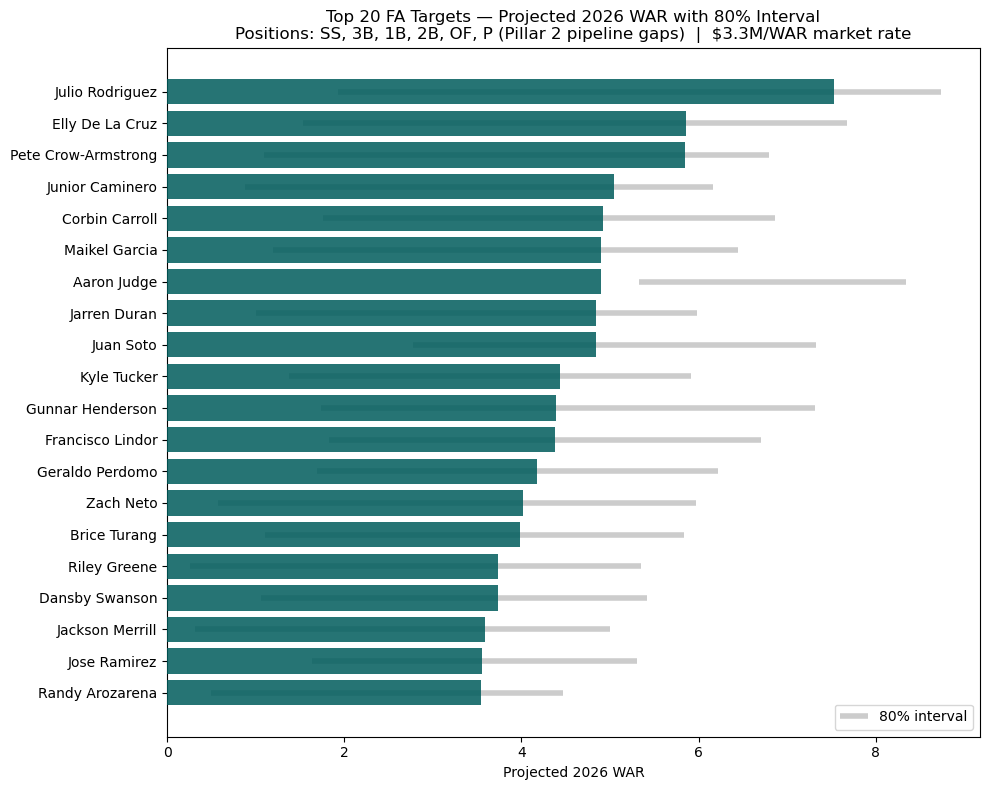

In [11]:
# Chart: top 20 by projected WAR with p10–p90 interval
top20 = output.head(20).iloc[::-1]  # reverse for horizontal bar readability

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top20["name_full"], top20["war_proj"], color="#005C5C", alpha=0.85, zorder=3)
ax.hlines(
    top20["name_full"],
    top20["war_low"], top20["war_high"],
    color="gray", linewidth=4, alpha=0.4, zorder=2, label="80% interval"
)

ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Projected 2026 WAR")
ax.set_title(
    f"Top 20 FA Targets — Projected 2026 WAR with 80% Interval\n"
    f"Positions: {', '.join(gap_positions)} (Pillar 2 pipeline gaps)  |  "
    f"${dollars_per_war:.1f}M/WAR market rate"
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../dashboard/tableau_data_extracts/fa_targets_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Export
export_path = "../dashboard/tableau_data_extracts/fa_targets.csv"
output.to_csv(export_path, index=False)
print(f"Exported {len(output)} FA targets → {export_path}")
print("Columns:", output.columns.tolist())

Exported 255 FA targets → ../dashboard/tableau_data_extracts/fa_targets.csv
Columns: ['mlbam_id', 'name_full', 'pos_group', 'age', 'war_y0', 'war_proj', 'war_low', 'war_high', 'proj_value_m', 'value_low_m', 'value_high_m']
